In [2]:
pip install qiskit


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4


In [3]:
pip install qiskit-Aer


# Estructura

{'00': 510, '11': 514}


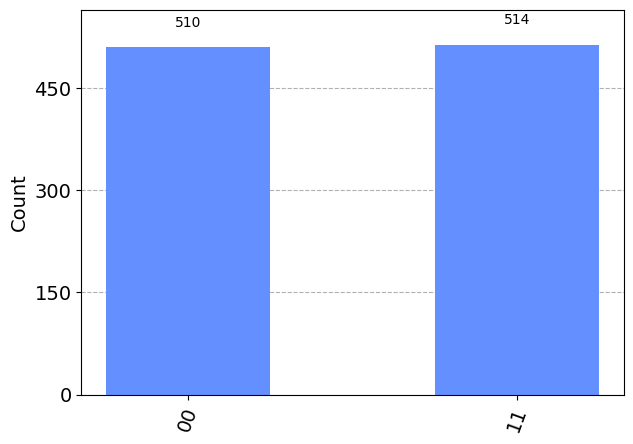

In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

#Definir cuicuito
qr = QuantumRegister(2,name='q')
cr = ClassicalRegister(2,name='c')
qc = QuantumCircuit (qr,cr)

# 2. Aplicar compuertas
qc.h(qr[0])
qc.cx(qr[0],qr[1])
qc.measure(qr,cr)

#3. Simular

sim = AerSimulator()
job = sim.run(qc,shots=1024)
counts = job.result().get_counts()

# 4. Visualization
print(counts)
plot_histogram(counts)

# Circuitos, Puertas y mediciones

## Puertas de un qubit

Las puertas de un qubit son matrices unitarias $2\times2$. La más importantes son:
$$H = \frac{1}{\sqrt{2}}\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}, \quad
X = \begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}, \quad
Z = \begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}, \quad
S = \begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}$$

$$R_x(\theta) = e^{-i\theta X/2}, \quad R_y(\theta) = e^{-i\theta Y/2}, \quad R_z(\theta) = e^{-i\theta Z/2}$$


   ┌───┐┌───┐┌───┐┌───┐┌───┐┌─────┐┌───┐┌─────┐┌─────────┐┌─────────┐»
q: ┤ X ├┤ Y ├┤ Z ├┤ H ├┤ S ├┤ Sdg ├┤ T ├┤ Tdg ├┤ Rx(π/3) ├┤ Ry(π/3) ├»
   └───┘└───┘└───┘└───┘└───┘└─────┘└───┘└─────┘└─────────┘└─────────┘»
«   ┌─────────┐┌────────────┐
«q: ┤ Rz(π/3) ├┤ U(π/2,0,π) ├
«   └─────────┘└────────────┘


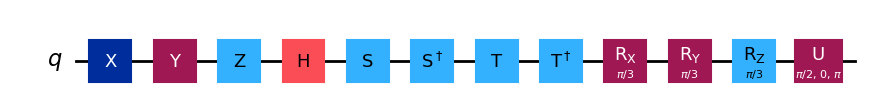

In [11]:
from qiskit import QuantumCircuit
import numpy as np

qc = QuantumCircuit(1)

# Puertas de Pauli
qc.x(0)
qc.y(0)
qc.z(0)

# Hadamard y fase
qc.h(0)
qc.s(0)
qc.sdg(0)
qc.t(0)
qc.tdg(0)

#Rotaciones parametrizadas
theta = np.pi/3
qc.rx(theta,0)
qc.ry(theta,0)
qc.rz(theta,0)

#Puerda universal U
qc.u(np.pi/2, 0, np.pi,0)

# visualizar
print(qc.draw('text'))
qc.draw('mpl')

## Puertas de dos y qubits



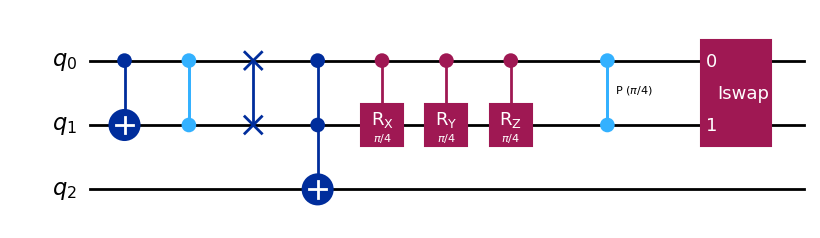

In [13]:
from qiskit import QuantumCircuit
import numpy as np
qc = QuantumCircuit(3)

#Cx: Control = 0, target 1
qc. cx(0,1)

#CZ: fase si ambos son |1>
qc. cz(0,1)

#SWAP: Intercambio dos qubits
qc.swap(0,1)

# Puerta de Toffoli
qc.ccx(0,1,2)

# CSWAP (fredkin): control + swap

#Rotaciones controladas
qc.crx(np.pi/4,0,1)
qc.cry(np.pi/4,0,1)
qc.crz(np.pi/4,0,1)
qc.cp(np.pi/4,0,1) #fase controlada

# ISWAP
qc.iswap(0,1)

qc.draw('mpl')



## Estados cuánticos y StateVector



In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import numpy as np

#Preparar estado de bell phi+
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

# Obtener el statevector
sv = Statevector (qc)
print("Statevector", sv)

#probabilidades de medición
probs = sv.probabilities_dict()
print("Probabilidades: ", probs)

# valor esperado de observable Z0 x Z1
from qiskit.quantum_info import SparsePauliOp
ZZ = SparsePauliOp('ZZ')
print("<ZZ>=", sv.expectation_value(ZZ).real)

#Matriz de densidad
rho = DensityMatrix(sv)

print("Pureza:", rho.purity().real)

#Traza parcial sobre qubit 1
rho_0 = partial_trace(rho,[1])
print("Estado reducido qubit 0 :")
print(rho_0.data)
print("Pureza reducida: ", rho_0.purity().real)

# Medir el statevector 
resultado, estado_colapsado = sv.measure()
print("Resultado medición: ", resultado ) 

Statevector Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Probabilidades:  {'00': 0.4999999999999999, '11': 0.4999999999999999}
<ZZ>= 0.9999999999999998
Pureza: 0.9999999999999996
Estado reducido qubit 0 :
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Pureza reducida:  0.4999999999999998
Resultado medición:  00


## Mediciones parciales y en bases arbitrarias

In [25]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

sim = AerSimulator()

# -------------------
# medición en base Z
# -------------------
qc_z = QuantumCircuit(1,1)
qc_z.h(0)
qc_z.measure(0,0)

c = sim.run([qc_z], shots=1024).result().get_counts()
print("base Z:", c)

# -------------------
# medición en base X
# -------------------
qc_x = QuantumCircuit(1,1)
qc_x.h(0)      # crea |+>
qc_x.h(0)      # rota base X -> Z
qc_x.measure(0,0)

c = sim.run([qc_x], shots=1024).result().get_counts()
print("base X:", c)

# -------------------
# medición en base Y
# -------------------
qc_y = QuantumCircuit(1,1)
qc_y.h(0)      # crea |+>
qc_y.sdg(0)    # rota base Y -> Z
qc_y.h(0)
qc_y.measure(0,0)

c = sim.run([qc_y], shots=1024).result().get_counts()
print("base Y:", c)

# -------------------
# medición de paridad
# -------------------
qc_par = QuantumCircuit(2,1)
qc_par.h(0)
qc_par.cx(0,1)
qc_par.cx(0,1)
qc_par.measure(0,0)

c = sim.run([qc_par], shots=1024).result().get_counts()
print("Par:", c)

# -------------------
# reset de qubit
# -------------------
qc_reset = QuantumCircuit(1,1)
qc_reset.h(0)
qc_reset.measure(0,0)
qc_reset.reset(0)

qc_reset.h(0)
qc_reset.measure(0,0)

base Z: {'0': 495, '1': 529}
base X: {'0': 1024}
base Y: {'1': 488, '0': 536}
Par: {'1': 534, '0': 490}


## Transpilación

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

qc = QuantumCircuit(3)
qc.h(0)
qc.ccx(0,1,2)

sim = AerSimulator()

qc_t = transpile(qc,sim, 
                 optimization_level =3,
                 basis_gates = ['cx','u'])

print(f"puertas originales: {qc.count_ops()}")
print(f"puertas transpiladas: {qc_t.count_ops()}")
print(f"profundidad original: {qc.depth()}")
print(f"profundidad transpilada: {qc_t.depth()}")



puertas originales: OrderedDict([('h', 1), ('ccx', 1)])
puertas transpiladas: OrderedDict([('u', 9), ('cx', 6)])
profundidad original: 2
profundidad transpilada: 11


# Algoritmos cuánticos

# Transformada de Fourier Cuántica


La QFT es la versión cuántica de la DFT. Actúa sobre la base computacional como:
$$QFT \ket{j} = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}e^{2\pi ijk/N}\ket{k}, \quad N=2^n$$
Es el subroutine central de Shor, QPE y otros algoritmos

QFT manual (4 qubits):


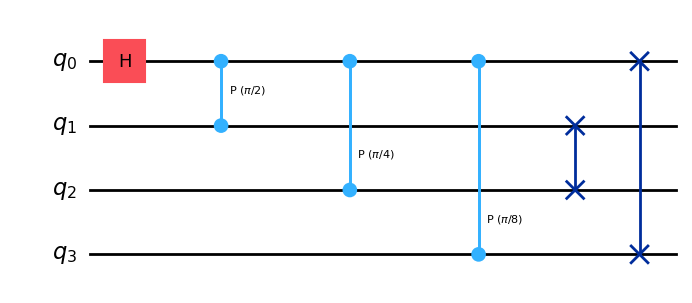

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
import numpy as np

def qft_manual(n):
    qc = QuantumCircuit(n)
    for j in range (n):
        qc.h(j)
        for k in range(j+1,n):
            qc.cp(2*np.pi/2**(k-j+1),k,j)
        for i in range(n//2):
            qc.swap(i,n-i-1)
        return qc

qft_4 = qft_manual(4)

print("QFT manual (4 qubits):")
qft_4.draw('mpl')

In [16]:
# Qft con qiskit
from qiskit.circuit.library import QFT
qft_qiskit = QFT(num_qubits=4, approximation_degree=0,do_swaps=True, inverse=False)

print(f"Profundidad QFT: {qft_qiskit.decompose().depth()}")
print(qft_qiskit.draw('text'))
qft_qiskit.draw('mpl')
iqft= QFT(4,inverse=True)
print(iqft.draw('text'))

Profundidad QFT: 8
     ┌──────┐
q_0: ┤0     ├
     │      │
q_1: ┤1     ├
     │  QFT │
q_2: ┤2     ├
     │      │
q_3: ┤3     ├
     └──────┘
     ┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1         ├
     │  IQFT_dg │
q_2: ┤2         ├
     │          │
q_3: ┤3         ├
     └──────────┘


## Estimación de fase cuántica

Quantum Phase Estimation estima la fase $\phi$ del autovalor $e^{2\pi \phi}$ de un operador unitario $U$, dado su autovector $\ket{u}$:
$$U\ket{u} = e^{2\pi i \phi}\ket{u}\rightarrow QPE: \ket{0}^{\otimes t}\ket{u}\rightarrow\ket{\bar{\phi}}\ket{u}$$


In [18]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseEstimation
from qiskit.quantum_info import Statevector
import numpy as np

n_conteo = 4

U = QuantumCircuit(1)
U.t(0)

psi = QuantumCircuit(1)
psi.x(0)

qpe = PhaseEstimation(n_conteo, U)

#Circuito completo

qc= QuantumCircuit(n_conteo +1)
qc.x(n_conteo)
qc.append(qpe, range(n_conteo+1))

sv = Statevector(qc)
probs = sv.probabilities_dict(qargs = range(n_conteo))

phi_estimado = int(max(probs, key=probs.get),2)/2**n_conteo
print(f"Fase estiamda: phi = {phi_estimado}")
print(f"Fase exacta: phi= {1/8}")

Fase estiamda: phi = 0.25
Fase exacta: phi= 0.125
